# 🛫 MÓDULO 1: Exploración de Datos
## Predicción de Retrasos Aéreos - American Regional Airways

**Objetivo:** Conocer el dataset y calcular estadísticas descriptivas básicas.

---

## 1.1 Configuración del Ambiente

Este código detecta automáticamente si estás en **Google Colab** o en **Docker**.

In [2]:
import sys

# Detectar ambiente
EN_COLAB = 'google.colab' in sys.modules

if EN_COLAB:
    print("📍 Ejecutando en Google Colab")
    !pip install pyspark -q
    from google.colab import drive
    drive.mount('/content/drive')
    RUTA_DATOS = '/content/drive/MyDrive/ML_Vuelos/data/'  # Ajustar según tu Drive
else:
    print("🐳 Ejecutando en Docker")
    RUTA_DATOS = '../data/'

print(f"\n📂 Ruta de datos: {RUTA_DATOS}")

🐳 Ejecutando en Docker

📂 Ruta de datos: ../data/


In [3]:
# Inicializar Spark
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Vuelos_Modulo1") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print(f"✅ Spark {spark.version} iniciado")

✅ Spark 3.5.0 iniciado


## 1.2 Cargar el Dataset

In [4]:
# Cargar datos de vuelos
df = spark.read.csv(
    RUTA_DATOS + "flights_2015_full.csv",
    header=True,
    inferSchema=True
)

print(f"✈️ Dataset cargado: {df.count():,} vuelos")
print(f"📊 Columnas: {len(df.columns)}")

✈️ Dataset cargado: 5,332,914 vuelos
📊 Columnas: 8


In [5]:
# Ver estructura
df.printSchema()

root
 |-- MONTH: integer (nullable = true)
 |-- DAY_OF_WEEK: integer (nullable = true)
 |-- AIRLINE: string (nullable = true)
 |-- ORIGIN: string (nullable = true)
 |-- DEST: string (nullable = true)
 |-- DEP_HOUR: integer (nullable = true)
 |-- DISTANCE: integer (nullable = true)
 |-- DEP_DEL15: integer (nullable = true)



In [6]:
# Primeras filas
df.show(5)

+-----+-----------+-------+------+----+--------+--------+---------+
|MONTH|DAY_OF_WEEK|AIRLINE|ORIGIN|DEST|DEP_HOUR|DISTANCE|DEP_DEL15|
+-----+-----------+-------+------+----+--------+--------+---------+
|    1|          4|     AS|   ANC| SEA|       0|    1448|        0|
|    1|          4|     AA|   LAX| PBI|       0|    2330|        0|
|    1|          4|     US|   SFO| CLT|       0|    2296|        0|
|    1|          4|     AA|   LAX| MIA|       0|    2342|        0|
|    1|          4|     AS|   SEA| ANC|       0|    1448|        0|
+-----+-----------+-------+------+----+--------+--------+---------+
only showing top 5 rows



## 1.3 Estadísticas Descriptivas

In [7]:
# Estadísticas numéricas
df.describe().show()

+-------+------------------+------------------+-------+-------+-------+-----------------+-----------------+-------------------+
|summary|             MONTH|       DAY_OF_WEEK|AIRLINE| ORIGIN|   DEST|         DEP_HOUR|         DISTANCE|          DEP_DEL15|
+-------+------------------+------------------+-------+-------+-------+-----------------+-----------------+-------------------+
|  count|           5332914|           5332914|5332914|5332914|5332914|          5332914|          5332914|            5332914|
|   mean| 6.207209979384629| 3.919178895440654|   NULL|   NULL|   NULL|13.03415468541214|822.8955314111572| 0.1869917647275017|
| stddev|3.3838067324499805|1.9936350491708552|   NULL|   NULL|   NULL|4.830332212803498|607.7991894508376|0.38990495400634445|
|    min|                 1|                 1|     AA|    ABE|    ABE|                0|               21|                  0|
|    max|                12|                 7|     WN|    YUM|    YUM|               23|             49

In [8]:
# Calcular tasa de retrasos
from pyspark.sql.functions import col, sum as spark_sum, count, round as spark_round

total_vuelos = df.count()
vuelos_retrasados = df.filter(col("DEP_DEL15") == 1).count()
tasa_retrasos = (vuelos_retrasados / total_vuelos) * 100

print("="*50)
print("📊 RESUMEN DEL DATASET")
print("="*50)
print(f"Total de vuelos:      {total_vuelos:>12,}")
print(f"Vuelos retrasados:    {vuelos_retrasados:>12,}")
print(f"Vuelos puntuales:     {total_vuelos - vuelos_retrasados:>12,}")
print(f"Tasa de retrasos:     {tasa_retrasos:>11.2f}%")
print("="*50)

📊 RESUMEN DEL DATASET
Total de vuelos:         5,332,914
Vuelos retrasados:         997,211
Vuelos puntuales:        4,335,703
Tasa de retrasos:           18.70%


## 1.4 Exploración por Variables

In [9]:
# Retrasos por MES
print("📅 RETRASOS POR MES")
df.groupBy("MONTH") \
    .agg(
        count("*").alias("total"),
        spark_sum("DEP_DEL15").alias("retrasados"),
        spark_round(spark_sum("DEP_DEL15") / count("*") * 100, 2).alias("tasa_%")
    ) \
    .orderBy("MONTH") \
    .show(12)

📅 RETRASOS POR MES
+-----+------+----------+------+
|MONTH| total|retrasados|tasa_%|
+-----+------+----------+------+
|    1|469968|     90978| 19.36|
|    2|429191|     91288| 21.27|
|    3|504312|     95585| 18.95|
|    4|485151|     79889| 16.47|
|    5|496993|     89816| 18.07|
|    6|503897|    116858| 23.19|
|    7|520718|    109884|  21.1|
|    8|510536|     96519| 18.91|
|    9|464946|     58488| 12.58|
|   11|467972|     69784| 14.91|
|   12|479230|     98122| 20.47|
+-----+------+----------+------+



In [10]:
# Retrasos por DÍA DE LA SEMANA
print("📆 RETRASOS POR DÍA (1=Lunes, 7=Domingo)")
df.groupBy("DAY_OF_WEEK") \
    .agg(
        count("*").alias("total"),
        spark_sum("DEP_DEL15").alias("retrasados"),
        spark_round(spark_sum("DEP_DEL15") / count("*") * 100, 2).alias("tasa_%")
    ) \
    .orderBy("DAY_OF_WEEK") \
    .show(7)

📆 RETRASOS POR DÍA (1=Lunes, 7=Domingo)
+-----------+------+----------+------+
|DAY_OF_WEEK| total|retrasados|tasa_%|
+-----------+------+----------+------+
|          1|799248|    158486| 19.83|
|          2|780858|    144666| 18.53|
|          3|790991|    144258| 18.24|
|          4|789594|    155958| 19.75|
|          5|779708|    147841| 18.96|
|          6|637814|    105701| 16.57|
|          7|754701|    140301| 18.59|
+-----------+------+----------+------+



In [11]:
# Retrasos por HORA DE SALIDA
print("🕐 RETRASOS POR HORA DE SALIDA")
df.groupBy("DEP_HOUR") \
    .agg(
        count("*").alias("total"),
        spark_sum("DEP_DEL15").alias("retrasados"),
        spark_round(spark_sum("DEP_DEL15") / count("*") * 100, 2).alias("tasa_%")
    ) \
    .orderBy("DEP_HOUR") \
    .show(24)

🕐 RETRASOS POR HORA DE SALIDA
+--------+------+----------+------+
|DEP_HOUR| total|retrasados|tasa_%|
+--------+------+----------+------+
|       0| 13720|      2339| 17.05|
|       1|  4920|       874| 17.76|
|       2|  1343|       230| 17.13|
|       3|   729|       154| 21.12|
|       4|   528|       127| 24.05|
|       5|108653|      6414|   5.9|
|       6|373324|     25009|   6.7|
|       7|359705|     32281|  8.97|
|       8|349326|     38893| 11.13|
|       9|321313|     42714| 13.29|
|      10|339876|     51551| 15.17|
|      11|327369|     54459| 16.64|
|      12|325368|     59017| 18.14|
|      13|333142|     64411| 19.33|
|      14|301763|     65223| 21.61|
|      15|336908|     75599| 22.44|
|      16|306418|     72842| 23.77|
|      17|357373|     89225| 24.97|
|      18|306560|     83310| 27.18|
|      19|303329|     83506| 27.53|
|      20|238717|     67255| 28.17|
|      21|172831|     46260| 26.77|
|      22|109059|     26895| 24.66|
|      23| 40640|      8623| 21.22

In [12]:
# Retrasos por AEROLÍNEA
print("✈️ RETRASOS POR AEROLÍNEA (ordenado por tasa)")
df.groupBy("AIRLINE") \
    .agg(
        count("*").alias("total"),
        spark_sum("DEP_DEL15").alias("retrasados"),
        spark_round(spark_sum("DEP_DEL15") / count("*") * 100, 2).alias("tasa_%")
    ) \
    .orderBy(col("tasa_%").desc()) \
    .show(15)

✈️ RETRASOS POR AEROLÍNEA (ordenado por tasa)
+-------+-------+----------+------+
|AIRLINE|  total|retrasados|tasa_%|
+-------+-------+----------+------+
|     NK| 107171|     29731| 27.74|
|     UA| 469829|    114059| 24.28|
|     F9|  82735|     19670| 23.77|
|     B6| 245135|     53697| 21.91|
|     WN|1157339|    251000| 21.69|
|     MQ| 272650|     53951| 19.79|
|     VX|  56439|     10170| 18.02|
|     AA| 648694|    114293| 17.62|
|     EV| 526249|     91185| 17.33|
|     OO| 539545|     90918| 16.85|
|     US| 198715|     29144| 14.67|
|     DL| 800329|    116765| 14.59|
|     AS| 158054|     17435| 11.03|
|     HA|  70030|      5193|  7.42|
+-------+-------+----------+------+



In [13]:
# Top 10 aeropuertos ORIGEN con más retrasos
print("🛫 TOP 10 AEROPUERTOS ORIGEN CON MÁS RETRASOS")
df.groupBy("ORIGIN") \
    .agg(
        count("*").alias("total"),
        spark_sum("DEP_DEL15").alias("retrasados"),
        spark_round(spark_sum("DEP_DEL15") / count("*") * 100, 2).alias("tasa_%")
    ) \
    .filter(col("total") > 10000) \
    .orderBy(col("tasa_%").desc()) \
    .show(10)

🛫 TOP 10 AEROPUERTOS ORIGEN CON MÁS RETRASOS
+------+------+----------+------+
|ORIGIN| total|retrasados|tasa_%|
+------+------+----------+------+
|   MDW| 80886|     19693| 24.35|
|   BWI| 86079|     20873| 24.25|
|   ORD|285884|     67810| 23.72|
|   DAL| 59699|     14050| 23.53|
|   HOU| 52042|     12183| 23.41|
|   EWR|101772|     23552| 23.14|
|   MIA| 69341|     16022| 23.11|
|   DEN|196055|     44426| 22.66|
|   PBI| 22573|      4967|  22.0|
|   LGA| 99605|     21529| 21.61|
+------+------+----------+------+
only showing top 10 rows



---
## ✅ CHECKPOINT MÓDULO 1

Antes de continuar, verifica que puedes responder:

1. ¿Cuántos vuelos tiene el dataset?
2. ¿Cuál es la tasa general de retrasos?
3. ¿Qué mes tiene más retrasos?
4. ¿Qué aerolínea tiene la peor tasa?

**Siguiente:** → `Modulo2_Preparacion.ipynb`

1. el data set tiene 5.332.914 vuelos
2. la tasa general de retrasos es de 18,70%
3. el mes con mas retrasos es junio con una tasa de retrasos de 23,19%
4. la aerolinea con la peor tasa de retrasos es NK con una tasa de 24,35%

exploracion para finanzas

In [35]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# 1. Calculamos la tabla base
df_finanzas_hora = df.groupBy("DEP_HOUR") \
    .agg(
        F.count("*").alias("total_vuelos"),
        F.sum("DEP_DEL15").alias("total_retrasos"),
        spark_round(spark_sum("DEP_DEL15") / count("*") * 100, 2).alias("tasa_%"),
        (F.sum("DEP_DEL15") * 150).alias("costo_compensacion_USD")
    )

# 2. Usamos una ventana para obtener el total global de costos
window_total = Window.partitionBy()
total_global_USD = F.sum("costo_compensacion_USD").over(window_total)

# 3. Añadimos la columna de proporción porcentual
df_final_DH = df_finanzas_hora.withColumn(
    "participacion_gasto_%", 
    F.round((F.col("costo_compensacion_USD") / total_global_USD) * 100, 2)
).orderBy(F.desc("total_retrasos"))

print("💰 IMPACTO FINANCIERO CON PARTICIPACIÓN PORCENTUAL(hora despegue)")
df_final_DH.show(10)

💰 IMPACTO FINANCIERO CON PARTICIPACIÓN PORCENTUAL(hora despegue)
+--------+------------+--------------+------+----------------------+---------------------+
|DEP_HOUR|total_vuelos|total_retrasos|tasa_%|costo_compensacion_USD|participacion_gasto_%|
+--------+------------+--------------+------+----------------------+---------------------+
|      17|      357373|         89225| 24.97|              13383750|                 8.95|
|      19|      303329|         83506| 27.53|              12525900|                 8.37|
|      18|      306560|         83310| 27.18|              12496500|                 8.35|
|      15|      336908|         75599| 22.44|              11339850|                 7.58|
|      16|      306418|         72842| 23.77|              10926300|                  7.3|
|      20|      238717|         67255| 28.17|              10088250|                 6.74|
|      14|      301763|         65223| 21.61|               9783450|                 6.54|
|      13|      333142|  

In [37]:
from pyspark.sql.functions import sum as spark_sum, count, lit


from pyspark.sql import functions as F
from pyspark.sql.window import Window

# 1. Calculamos la tabla base
df_finanzas_airl = df.groupBy("AIRLINE") \
    .agg(
        F.count("*").alias("total_vuelos"),
        F.sum("DEP_DEL15").alias("total_retrasos"),
        spark_round(spark_sum("DEP_DEL15") / count("*") * 100, 2).alias("tasa_%"),
        (F.sum("DEP_DEL15") * 150).alias("costo_compensacion_USD")
    )

# 2. Usamos una ventana para obtener el total global de costos
window_total = Window.partitionBy()
total_global_USD = F.sum("costo_compensacion_USD").over(window_total)

# 3. Añadimos la columna de proporción porcentual
df_final_A = df_finanzas_airl.withColumn(
    "participacion_gasto_%", 
    F.round((F.col("costo_compensacion_USD") / total_global_USD) * 100, 2)
).orderBy(F.desc("total_retrasos"))

print("💰 IMPACTO FINANCIERO CON PARTICIPACIÓN PORCENTUAL(airline)")
df_final_A.show(10)

💰 IMPACTO FINANCIERO CON PARTICIPACIÓN PORCENTUAL(airline)
+-------+------------+--------------+------+----------------------+---------------------+
|AIRLINE|total_vuelos|total_retrasos|tasa_%|costo_compensacion_USD|participacion_gasto_%|
+-------+------------+--------------+------+----------------------+---------------------+
|     WN|     1157339|        251000| 21.69|              37650000|                25.17|
|     DL|      800329|        116765| 14.59|              17514750|                11.71|
|     AA|      648694|        114293| 17.62|              17143950|                11.46|
|     UA|      469829|        114059| 24.28|              17108850|                11.44|
|     EV|      526249|         91185| 17.33|              13677750|                 9.14|
|     OO|      539545|         90918| 16.85|              13637700|                 9.12|
|     MQ|      272650|         53951| 19.79|               8092650|                 5.41|
|     B6|      245135|         53697| 21.

In [38]:
from pyspark.sql.functions import sum as spark_sum, count, lit

from pyspark.sql import functions as F
from pyspark.sql.window import Window

# 1. Calculamos la tabla base
df_finanzas_airl = df.groupBy("ORIGIN") \
    .agg(
        F.count("*").alias("total_vuelos"),
        F.sum("DEP_DEL15").alias("total_retrasos"),
        spark_round(spark_sum("DEP_DEL15") / count("*") * 100, 2).alias("tasa_%"),
        (F.sum("DEP_DEL15") * 150).alias("costo_compensacion_USD")
    )

# 2. Usamos una ventana para obtener el total global de costos
window_total = Window.partitionBy()
total_global_USD = F.sum("costo_compensacion_USD").over(window_total)

# 3. Añadimos la columna de proporción porcentual
df_final_O = df_finanzas_airl.withColumn(
    "participacion_gasto_%", 
    F.round((F.col("costo_compensacion_USD") / total_global_USD) * 100, 2)
).orderBy(F.desc("total_retrasos"))

print("💰 IMPACTO FINANCIERO CON PARTICIPACIÓN PORCENTUAL(origen)")
df_final_O.show(10)

💰 IMPACTO FINANCIERO CON PARTICIPACIÓN PORCENTUAL(origen)
+------+------------+--------------+------+----------------------+---------------------+
|ORIGIN|total_vuelos|total_retrasos|tasa_%|costo_compensacion_USD|participacion_gasto_%|
+------+------------+--------------+------+----------------------+---------------------+
|   ORD|      285884|         67810| 23.72|              10171500|                  6.8|
|   ATL|      346836|         61670| 17.78|               9250500|                 6.18|
|   DFW|      239551|         51605| 21.54|               7740750|                 5.17|
|   DEN|      196055|         44426| 22.66|               6663900|                 4.46|
|   LAX|      194673|         40835| 20.98|               6125250|                 4.09|
|   IAH|      146622|         30873| 21.06|               4630950|                  3.1|
|   SFO|      148008|         30464| 20.58|               4569600|                 3.05|
|   LAS|      133181|         28688| 21.54|         

In [39]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# 1. Calculamos la tabla base
df_finanzas_hora = df.groupBy("MONTH") \
    .agg(
        F.count("*").alias("total_vuelos"),
        F.sum("DEP_DEL15").alias("total_retrasos"),
        spark_round(spark_sum("DEP_DEL15") / count("*") * 100, 2).alias("tasa_%"),
        (F.sum("DEP_DEL15") * 150).alias("costo_compensacion_USD")
    )

# 2. Usamos una ventana para obtener el total global de costos
window_total = Window.partitionBy()
total_global_USD = F.sum("costo_compensacion_USD").over(window_total)

# 3. Añadimos la columna de proporción porcentual
df_final_M = df_finanzas_hora.withColumn(
    "participacion_gasto_%", 
    F.round((F.col("costo_compensacion_USD") / total_global_USD) * 100, 2)
).orderBy(F.desc("total_retrasos"))

print("💰 IMPACTO FINANCIERO CON PARTICIPACIÓN PORCENTUAL(mes)")
df_final_M.show(10)

💰 IMPACTO FINANCIERO CON PARTICIPACIÓN PORCENTUAL(mes)
+-----+------------+--------------+------+----------------------+---------------------+
|MONTH|total_vuelos|total_retrasos|tasa_%|costo_compensacion_USD|participacion_gasto_%|
+-----+------------+--------------+------+----------------------+---------------------+
|    6|      503897|        116858| 23.19|              17528700|                11.72|
|    7|      520718|        109884|  21.1|              16482600|                11.02|
|   12|      479230|         98122| 20.47|              14718300|                 9.84|
|    8|      510536|         96519| 18.91|              14477850|                 9.68|
|    3|      504312|         95585| 18.95|              14337750|                 9.59|
|    2|      429191|         91288| 21.27|              13693200|                 9.15|
|    1|      469968|         90978| 19.36|              13646700|                 9.12|
|    5|      496993|         89816| 18.07|              13472400|

/tmp/ipykernel_7777/3604942500.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x="DEP_HOUR", y="costo_compensacion_USD", data=df_plot_hour,


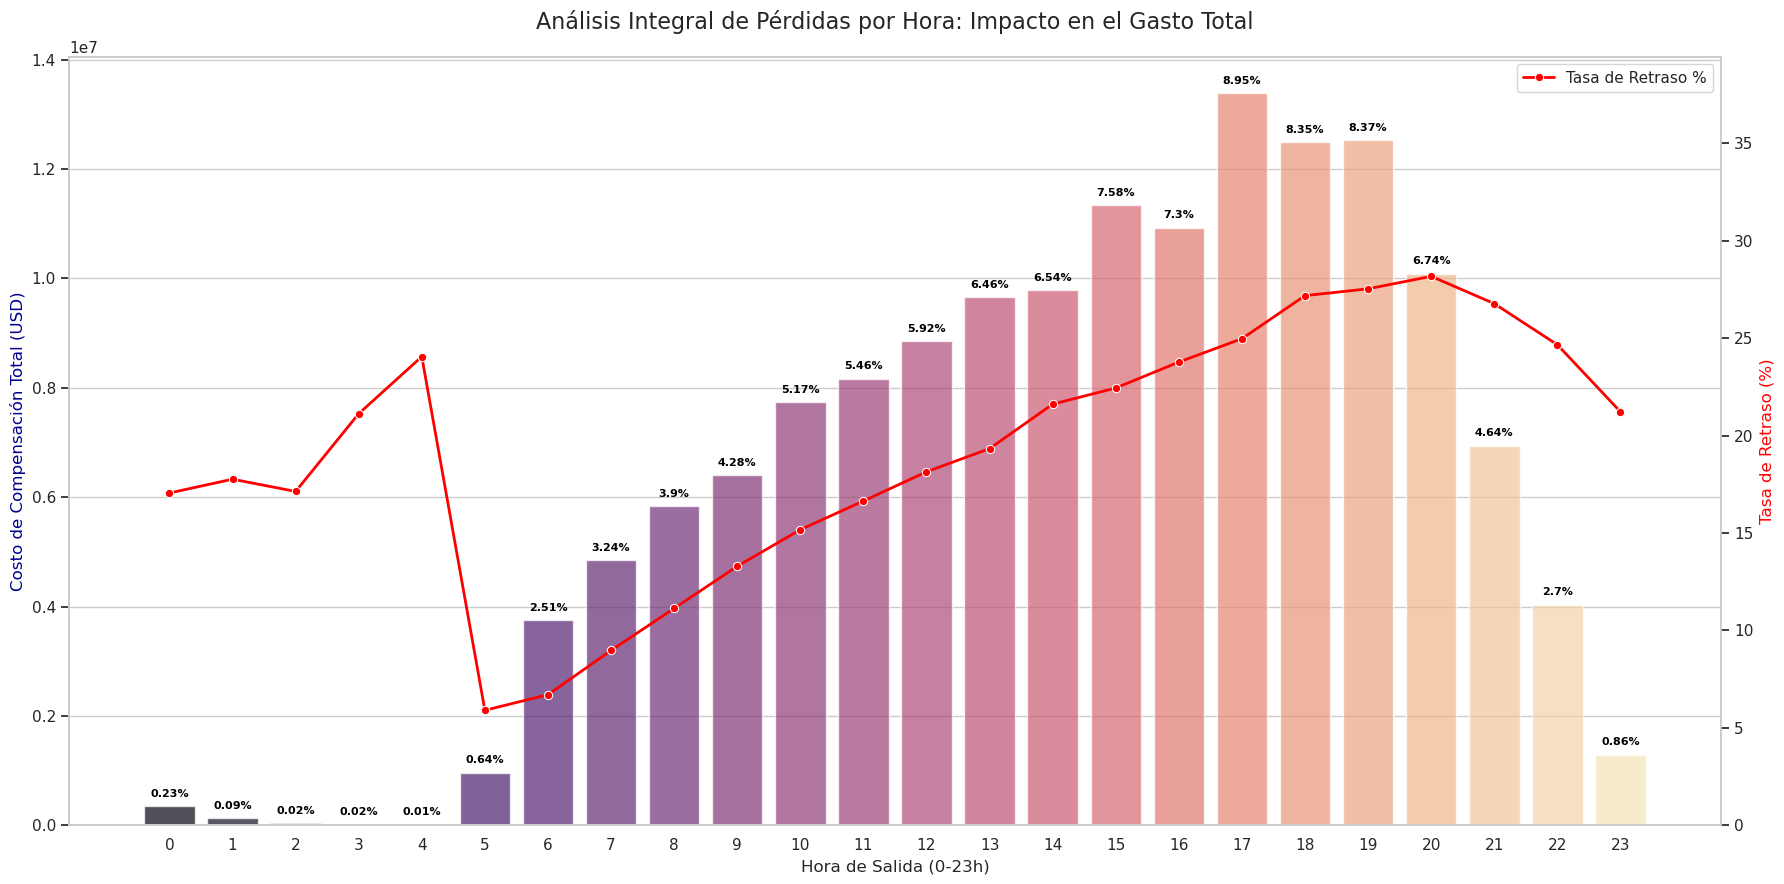

<Figure size 640x480 with 0 Axes>

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convertimos el resultado de Spark a Pandas
df_plot_hour = df_final_DH.orderBy("DEP_HOUR").toPandas()

# 2. Configuración del lienzo
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(18, 9)) # Aumentamos un poco el ancho para dar aire a las etiquetas

# 3. Gráfico de Barras (Costo en USD por hora)
bars = sns.barplot(x="DEP_HOUR", y="costo_compensacion_USD", data=df_plot_hour, 
                   ax=ax1, palette="magma", alpha=0.7)

# 4. AGREGAR ETIQUETAS DE PARTICIPACIÓN (%) SOBRE TODAS LAS BARRAS
for i, bar in enumerate(bars.patches):
    valor_pct = df_plot_hour["participacion_gasto_%"].iloc[i]
    # Colocamos la etiqueta en todas las barras sin restricciones
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (df_plot_hour["costo_compensacion_USD"].max() * 0.01),
        f'{valor_pct}%',
        ha='center', va='bottom', 
        fontsize=8, # Tamaño ligeramente más pequeño para evitar colisiones
        fontweight='bold', 
        color='black',
        rotation=0 # Puedes poner 45 si ves que se solapan mucho
    )

# 5. Configuración del Eje Principal (Barras)
ax1.set_ylabel("Costo de Compensación Total (USD)", fontsize=12, color='darkblue')
ax1.set_xlabel("Hora de Salida (0-23h)", fontsize=12)
ax1.set_title("Análisis Integral de Pérdidas por Hora: Impacto en el Gasto Total", fontsize=16, pad=20)

# 6. Segundo Eje (Línea de Tasa de Retraso %)
ax2 = ax1.twinx()
# Usamos df_plot_hour.index para asegurar que la línea alinee con las barras
sns.lineplot(x=range(len(df_plot_hour)), y=df_plot_hour["tasa_%"], ax=ax2, 
             marker="o", color="red", linewidth=2, label="Tasa de Retraso %")

ax2.set_ylabel("Tasa de Retraso (%)", fontsize=12, color='red')
ax2.set_ylim(0, df_plot_hour["tasa_%"].max() * 1.4) # Más margen arriba para las etiquetas
ax2.grid(False)

# 7. Ajustes finales
plt.tight_layout()
plt.show()
# 7. Ajustes finales
plt.tight_layout()
plt.show()

/tmp/ipykernel_7777/2692528106.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x="AIRLINE", y="costo_compensacion_USD", data=df_plot,


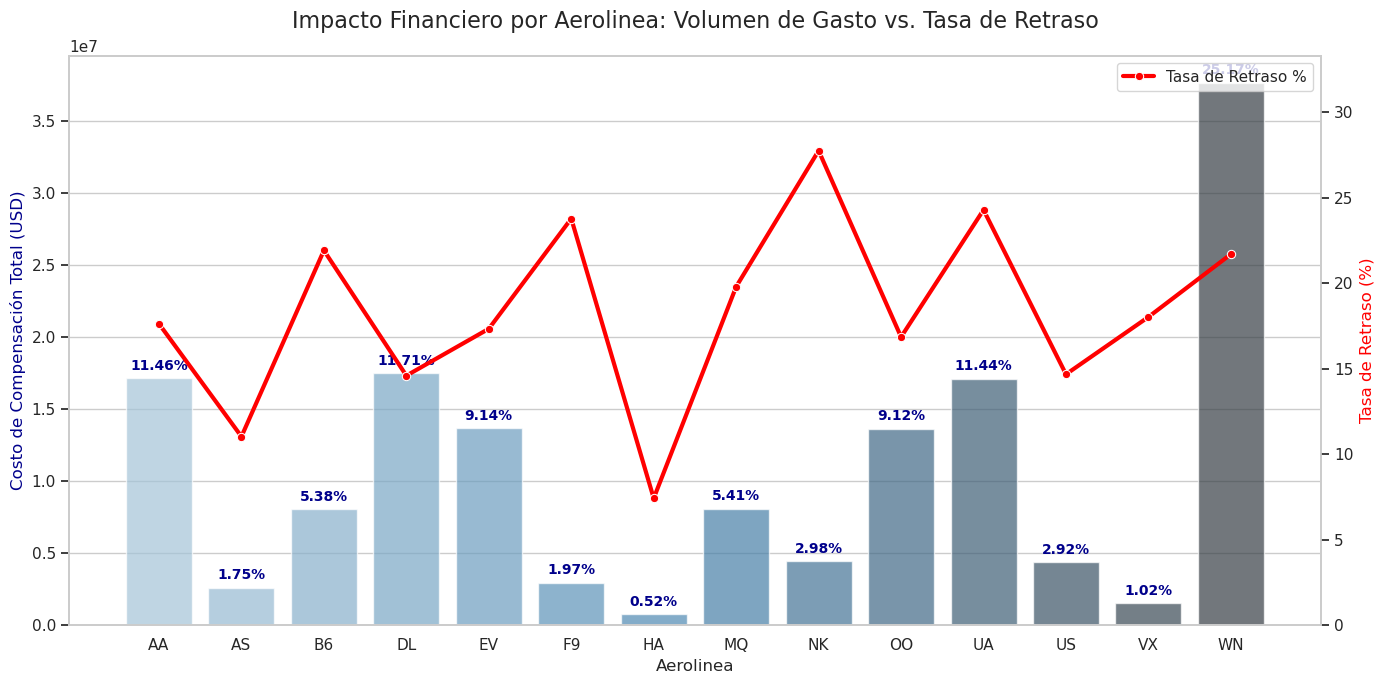

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convertimos el resultado de Spark a Pandas para graficar
df_plot = df_final_A.orderBy("AIRLINE").toPandas()

# 2. Configuración del estilo y lienzos
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(14, 7))

# 3. Gráfico de Barras (Costo en USD)
# Guardamos el objeto barplot para poder acceder a las barras después
bars = sns.barplot(x="AIRLINE", y="costo_compensacion_USD", data=df_plot, 
                   ax=ax1, palette="Blues_d", alpha=0.7)

# 4. AGREGAR ETIQUETAS DE PARTICIPACIÓN (%) SOBRE LAS BARRAS
# Iteramos sobre las barras y los valores de participación del DataFrame
for i, bar in enumerate(bars.patches):
    valor_pct = df_plot["participacion_gasto_%"].iloc[i]
    ax1.text(
        bar.get_x() + bar.get_width() / 2, # Posición X (centro de la barra)
        bar.get_height() + (df_plot["costo_compensacion_USD"].max() * 0.01), # Posición Y (un poco arriba del tope)
        f'{valor_pct}%', # Texto a mostrar
        ha='center', va='bottom', fontsize=10, fontweight='bold', color='darkblue'
    )

# 5. Configuración del Eje Principal (Barras)
ax1.set_ylabel("Costo de Compensación Total (USD)", fontsize=12, color='darkblue')
ax1.set_xlabel("Aerolinea", fontsize=12)
ax1.set_title("Impacto Financiero por Aerolinea: Volumen de Gasto vs. Tasa de Retraso", fontsize=16, pad=20)

# 6. Segundo Eje (Línea de Tasa de Retraso %)
ax2 = ax1.twinx()
sns.lineplot(x=range(len(df_plot)), y=df_plot["tasa_%"], ax=ax2, 
             marker="o", color="red", linewidth=3, label="Tasa de Retraso %")

ax2.set_ylabel("Tasa de Retraso (%)", fontsize=12, color='red')
ax2.set_ylim(0, df_plot["tasa_%"].max() * 1.2) # Damos aire arriba para que no choque
ax2.grid(False)

# 7. Ajustes finales y mostrar
plt.tight_layout()
plt.show()

/tmp/ipykernel_7777/4093829191.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x="ORIGIN", y="costo_compensacion_USD", data=df_plot,


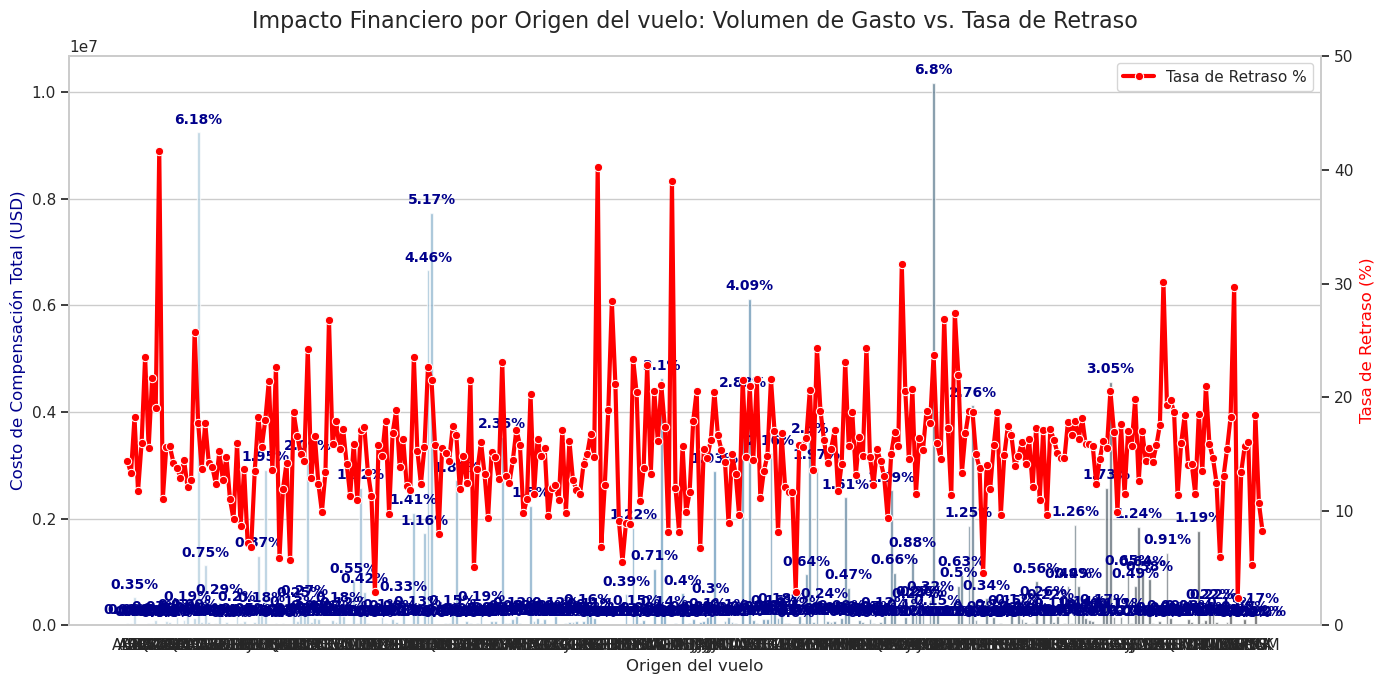

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convertimos el resultado de Spark a Pandas para graficar
df_plot = df_final_O.orderBy("ORIGIN").toPandas()

# 2. Configuración del estilo y lienzos
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(14, 7))

# 3. Gráfico de Barras (Costo en USD)
# Guardamos el objeto barplot para poder acceder a las barras después
bars = sns.barplot(x="ORIGIN", y="costo_compensacion_USD", data=df_plot, 
                   ax=ax1, palette="Blues_d", alpha=0.7)

# 4. AGREGAR ETIQUETAS DE PARTICIPACIÓN (%) SOBRE LAS BARRAS
# Iteramos sobre las barras y los valores de participación del DataFrame
for i, bar in enumerate(bars.patches):
    valor_pct = df_plot["participacion_gasto_%"].iloc[i]
    ax1.text(
        bar.get_x() + bar.get_width() / 2, # Posición X (centro de la barra)
        bar.get_height() + (df_plot["costo_compensacion_USD"].max() * 0.01), # Posición Y (un poco arriba del tope)
        f'{valor_pct}%', # Texto a mostrar
        ha='center', va='bottom', fontsize=10, fontweight='bold', color='darkblue'
    )

# 5. Configuración del Eje Principal (Barras)
ax1.set_ylabel("Costo de Compensación Total (USD)", fontsize=12, color='darkblue')
ax1.set_xlabel("Origen del vuelo", fontsize=12)
ax1.set_title("Impacto Financiero por Origen del vuelo: Volumen de Gasto vs. Tasa de Retraso", fontsize=16, pad=20)

# 6. Segundo Eje (Línea de Tasa de Retraso %)
ax2 = ax1.twinx()
sns.lineplot(x=range(len(df_plot)), y=df_plot["tasa_%"], ax=ax2, 
             marker="o", color="red", linewidth=3, label="Tasa de Retraso %")

ax2.set_ylabel("Tasa de Retraso (%)", fontsize=12, color='red')
ax2.set_ylim(0, df_plot["tasa_%"].max() * 1.2) # Damos aire arriba para que no choque
ax2.grid(False)

# 7. Ajustes finales y mostrar
plt.tight_layout()
plt.show()

/tmp/ipykernel_7777/3215545149.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x="MONTH", y="costo_compensacion_USD", data=df_plot,


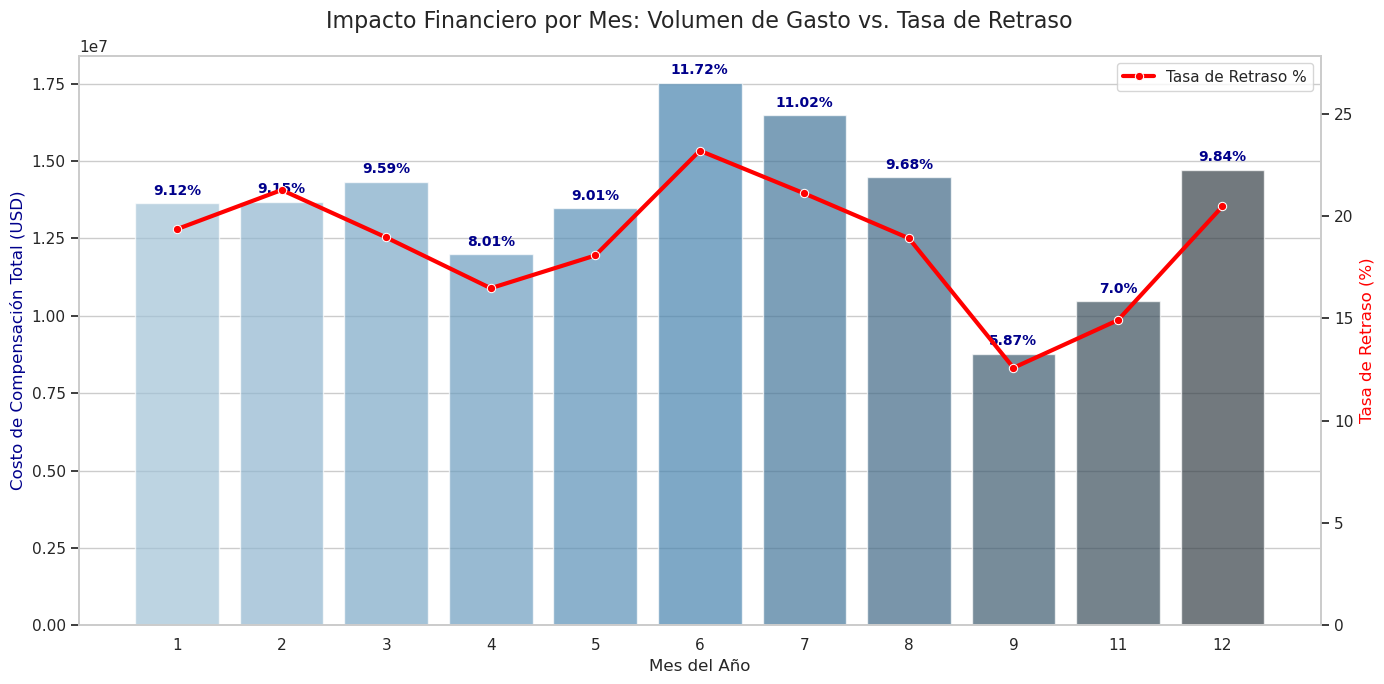

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convertimos el resultado de Spark a Pandas para graficar
df_plot = df_final.orderBy("MONTH").toPandas()

# 2. Configuración del estilo y lienzos
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(14, 7))

# 3. Gráfico de Barras (Costo en USD)
# Guardamos el objeto barplot para poder acceder a las barras después
bars = sns.barplot(x="MONTH", y="costo_compensacion_USD", data=df_plot, 
                   ax=ax1, palette="Blues_d", alpha=0.7)

# 4. AGREGAR ETIQUETAS DE PARTICIPACIÓN (%) SOBRE LAS BARRAS
# Iteramos sobre las barras y los valores de participación del DataFrame
for i, bar in enumerate(bars.patches):
    valor_pct = df_plot["participacion_gasto_%"].iloc[i]
    ax1.text(
        bar.get_x() + bar.get_width() / 2, # Posición X (centro de la barra)
        bar.get_height() + (df_plot["costo_compensacion_USD"].max() * 0.01), # Posición Y (un poco arriba del tope)
        f'{valor_pct}%', # Texto a mostrar
        ha='center', va='bottom', fontsize=10, fontweight='bold', color='darkblue'
    )

# 5. Configuración del Eje Principal (Barras)
ax1.set_ylabel("Costo de Compensación Total (USD)", fontsize=12, color='darkblue')
ax1.set_xlabel("Mes del Año", fontsize=12)
ax1.set_title("Impacto Financiero por Mes: Volumen de Gasto vs. Tasa de Retraso", fontsize=16, pad=20)

# 6. Segundo Eje (Línea de Tasa de Retraso %)
ax2 = ax1.twinx()
sns.lineplot(x=range(len(df_plot)), y=df_plot["tasa_%"], ax=ax2, 
             marker="o", color="red", linewidth=3, label="Tasa de Retraso %")

ax2.set_ylabel("Tasa de Retraso (%)", fontsize=12, color='red')
ax2.set_ylim(0, df_plot["tasa_%"].max() * 1.2) # Damos aire arriba para que no choque
ax2.grid(False)

# 7. Ajustes finales y mostrar
plt.tight_layout()
plt.show()